# GBDT 特征提取与应用

## 1. 学习目标

通过本章的学习，读者将能够：

1. **理解** GBDT 模型作为特征提取器的核心思想与优势。
2. **掌握** 叶子索引编码（Leaf Index Encoding）的原理及计算过程。
3. **熟悉** GBDT 特征提取的完整工程流程（从训练基模型到生成新特征）。
4. **应用** Python 工具（LightGBM、Scikit-learn）实现 "GBDT + LR" 的经典组合模型。
5. **了解** GBDT 特征提取在推荐系统（如 CTR 预估）等工业场景中的应用。

---

## 2. 引言

在机器学习任务中，特征工程是影响模型性能的关键因素之一。如何从原始数据中提取有意义的特征，不仅直接决定了模型的最终效果，还影响着模型的泛化能力和鲁棒性。

通常我们认为 **GBDT**（Gradient Boosting Decision Tree，梯度提升决策树）是一种强大的分类和回归算法，但实际上，它还可以被用作一个高效的**特征提取器**。树模型通过递归分裂天然具备特征选择和组合的能力，能够自动捕捉高阶非线性关系。将 GBDT 提取的特征输入到下游模型（如逻辑回归）中，往往能取得比单一模型更好的效果。

---

## 3. GBDT 简介

**GBDT** 是一种集成学习方法，通过构建多个弱决策树（通常是 CART 树）来提升整体模型的预测能力。相比于随机森林（Random Forest），GBDT 采用的是 **Boosting**（提升）策略，即每一棵树都在尝试修正前一棵树的错误。

**GBDT 的核心优势包括：**

- **非线性建模能力强**：能够自动发现特征间的高阶组合关系。
- **鲁棒性好**：对异常值和缺失值有较好的容忍度。
- **实现高效**：现代实现（如 LightGBM、XGBoost）支持并行计算，适用于海量数据。

常见的 GBDT 实现库包括：

- `sklearn.ensemble.GradientBoostingClassifier`：适合中小规模数据，易于上手。
- `XGBoost`：工业界经典之作，支持高效并行和正则化。
- `LightGBM`：微软开源，采用直方图算法和 GOSS 采样，速度极快，内存占用低。
- `CatBoost`：对类别特征处理友好，减少了繁琐的预处理工作。

---

## 4. GBDT 特征提取的原理

GBDT 进行特征提取的核心思想是将样本在树中的**路径信息**转化为新的特征表示。主要方式有以下几种：

### 4.1 叶子索引编码（Leaf Index Encoding）

这是最经典的方法。GBDT 训练完成后，由 $N$ 棵树组成。对于任意一个样本，它在每一棵树中都会落入一个唯一的**叶子节点**。

我们将样本在每棵树中落入的叶子节点的索引（Index）收集起来，就形成了一个长度为 $N$ 的新特征向量。由于叶子索引是离散的类别型数据，通常需要进一步进行 **One-Hot 编码** 或 **Embedding**，将其转换为高维稀疏向量或低维稠密向量。

#### 4.1.1 手动计算示例

假设我们有一个训练好的 GBDT 模型，由 **3 棵决策树** 组成，每棵树的叶子节点编号如下：

- **第一棵树**：`[0, 1, 2, 3]` （共 4 个叶子）
- **第二棵树**：`[0, 1]` （共 2 个叶子）
- **第三棵树**：`[0, 1, 2]` （共 3 个叶子）

**步骤 1：确定样本的叶子索引**：

假设一个样本 $x$，在预测时落入以下位置：

- 第一棵树 $\rightarrow$ 叶子节点 `2`
- 第二棵树 $\rightarrow$ 叶子节点 `1`
- 第三棵树 $\rightarrow$ 叶子节点 `0`

该样本的**叶子索引特征**为：`[2, 1, 0]`。

**步骤 2：One-Hot 编码**：

将上述索引转换为 One-Hot 向量：

- 第一棵树（4 叶子）：`2` $\rightarrow$ `[0, 0, 1, 0]`
- 第二棵树（2 叶子）：`1` $\rightarrow$ `[0, 1]`
- 第三棵树（3 叶子）：`0` $\rightarrow$ `[1, 0, 0]`

拼接所有向量，得到最终的**高维稀疏特征**：



```text
[0, 0, 1, 0, 0, 1, 1, 0, 0]
```



这种表示方式通过树结构将原始特征进行了非线性变换和组合。

### 4.2 特征重要性（Feature Importance）

除了直接提取特征，GBDT 还可以帮助我们筛选特征。常见的评估指标包括：

- **Split（分裂次数）**：特征被用于分裂的总次数（LightGBM 默认）。
- **Gain（信息增益）**：特征分裂带来的信息增益总和（XGBoost 常用），更能反映特征的区分度。

### 4.3 SHAP 值解释

**SHAP (SHapley Additive exPlanations)** 基于博弈论，能够量化每个特征对单个预测结果的贡献值（正向或负向）。相比传统的重要性排序，SHAP 提供了更细粒度的解释，不仅能用于特征选择，还能生成新的强解释性特征。

---

## 5. GBDT 特征提取的流程

在实际工程中，GBDT 特征提取通常遵循以下标准流程：

### 5.1 训练 GBDT 模型

使用完整数据集训练 GBDT 基准模型。

> **注意**：需严格控制过拟合。特征提取模型的目的不是追求极致的预测准确率，而是为了生成有代表性的结构特征。可通过限制树深（`max_depth`）、增加叶子节点最小样本数（`min_data_in_leaf`）等方式控制模型复杂度。

### 5.2 提取叶子索引

调用模型的预测接口（如 LightGBM 的 `predict(..., pred_leaf=True)`），输出样本在所有树上的叶子索引矩阵。矩阵形状为 `(n_samples, n_trees)`。

### 5.3 特征变换

使用 `OneHotEncoder` 对叶子索引矩阵进行编码。

> **关键点**：训练集和测试集必须使用**同一个** Encoder 进行转换，确保特征维度和含义一致。

### 5.4 融合与训练下游模型

将编码后的 GBDT 特征与原始特征（可选）拼接，输入到下游模型（如逻辑回归 LR、FM 或 DNN）中进行最终训练。

---

## 6. Python 代码示例

以下示例演示如何使用 `LightGBM` 提取特征，并结合 `LogisticRegression` 完成分类任务。

### 6.1 环境准备

确保已安装必要的库：



In [8]:
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
import warnings

# 忽略 SHAP 和 LightGBM 的特定警告
warnings.filterwarnings('ignore', message='LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')
warnings.filterwarnings('ignore', message='X does not have valid feature names')
# 忽略 NumPy RNG FutureWarning (来自 shap.summary_plot)
warnings.filterwarnings('ignore', category=FutureWarning, message='.*NumPy global RNG.*')

# 1. 生成模拟数据集
# 1000个样本，10个特征
np.random.seed(42)
# 使用 DataFrame 并指定列名，避免 LightGBM 警告
feature_names = [f'feature_{i}' for i in range(10)]
X = pd.DataFrame(np.random.rand(1000, 10), columns=feature_names)
# 生成二分类标签：前两个特征之和大于1则为正样本
y = (X.iloc[:, 0] + X.iloc[:, 1] > 1).astype(int)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. 训练 GBDT (LightGBM) 模型
# 设置 n_estimators=100 (100棵树), num_leaves=31 (每棵树最多31个叶子)
# verbosity=-1 和 force_col_wise=True 用于抑制警告并加速
print("正在训练 LightGBM 模型...")
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    num_leaves=31,
    random_state=42,
    verbosity=-1,
    force_col_wise=True
)
lgb_model.fit(X_train, y_train)

# --- 新增：SHAP 值解释 ---
print("正在计算 SHAP 值...")
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_train)
# 注意：shap_values 对于二分类可能是 list，取索引 1 (正类)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# 3. 提取叶子索引特征
# pred_leaf=True 返回每个样本在每棵树上的叶子节点索引
print("正在提取叶子索引特征...")
X_train_leaves = lgb_model.predict(X_train, pred_leaf=True)
X_test_leaves = lgb_model.predict(X_test, pred_leaf=True)

print(f"叶子索引矩阵形状 (训练集): {X_train_leaves.shape}")
# 输出应为 (800, 100)，即 800个样本，100棵树

# 4. One-Hot 编码
# 将离散的叶子索引转换为稀疏的 0/1 特征
encoder = OneHotEncoder(categories='auto', sparse_output=False, handle_unknown='ignore')
X_train_encoded = encoder.fit_transform(X_train_leaves)
X_test_encoded = encoder.transform(X_test_leaves)

print(f"One-Hot 编码后特征维度: {X_train_encoded.shape}")

# 5. 特征融合 (原始特征 + GBDT特征)
# 为了让 LR 同时利用线性规律和非线性规律，通常将两者拼接
# 注意：原始特征建议做归一化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_final = np.hstack([X_train_scaled, X_train_encoded])
X_test_final = np.hstack([X_test_scaled, X_test_encoded])

print(f"融合后特征维度: {X_train_final.shape}")

# 6. 训练下游模型 (逻辑回归 LR)
print("正在训练逻辑回归模型...")
# 使用 saga 求解器支持 ElasticNet (l1_ratio=1 等价于 L1 正则)
# L1 正则化有助于筛选掉无用的叶子特征
lr = LogisticRegression(
    solver='saga',
    l1_ratio=1,
    C=1.0,
    max_iter=5000  # 增加迭代次数以保证收敛
)
lr.fit(X_train_final, y_train)

# 7. 评估模型
y_pred = lr.predict(X_test_final)
y_prob = lr.predict_proba(X_test_final)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"\n=== 模型评估结果 ===")
print(f"LR 准确率 (Accuracy): {acc:.4f}")
print(f"LR AUC 分数: {auc:.4f}")


正在训练 LightGBM 模型...
正在计算 SHAP 值...
正在提取叶子索引特征...
叶子索引矩阵形状 (训练集): (800, 100)
One-Hot 编码后特征维度: (800, 3038)
融合后特征维度: (800, 3048)
正在训练逻辑回归模型...

=== 模型评估结果 ===
LR 准确率 (Accuracy): 0.9900
LR AUC 分数: 0.9998



### 6.2 完整代码实现



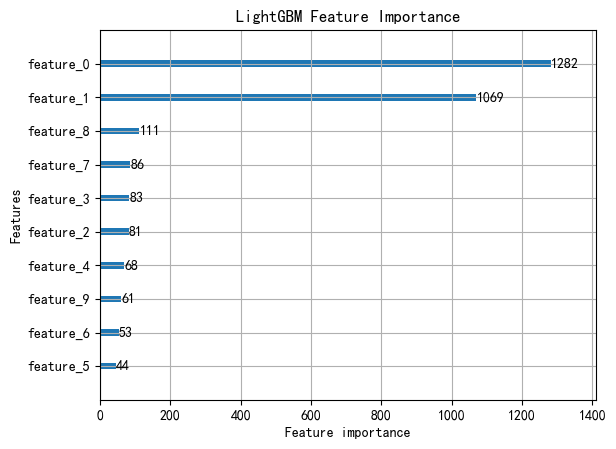

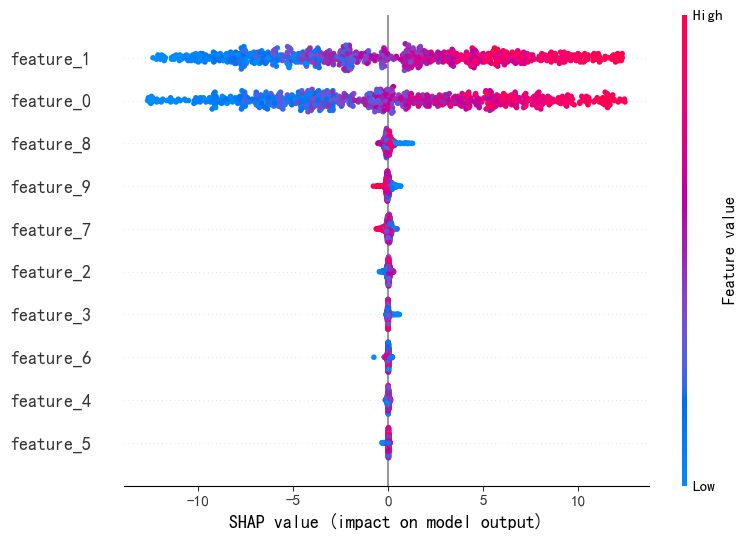

In [9]:
# 1. LightGBM 自带特征重要性
lgb.plot_importance(lgb_model, max_num_features=10, title="LightGBM Feature Importance")
plt.show()

# 2. SHAP 摘要图 (Summary Plot)
# 展示每个特征对预测结果的影响方向和程度
shap.summary_plot(shap_values, X_train, max_display=10)



### 6.3 结果可视化：特征重要性



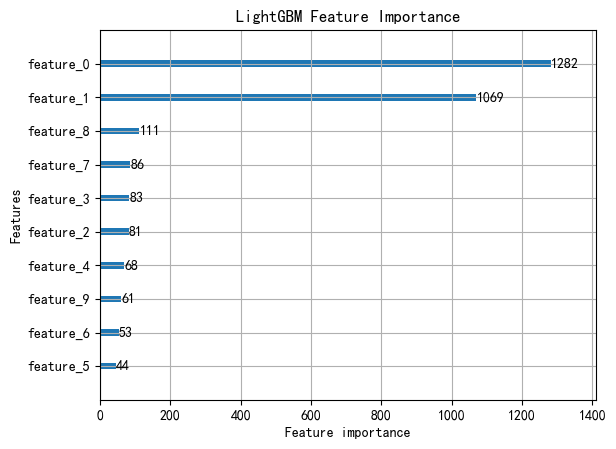

In [10]:
# 可视化 GBDT 的特征重要性
lgb.plot_importance(lgb_model, max_num_features=10, title="LightGBM Feature Importance")
plt.show()



---

## 7. GBDT 特征提取的应用场景

### 7.1 CTR 预估与推荐系统

这是 GBDT 特征提取最著名的应用场景。2014 年，**Facebook** 在论文《Practical Lessons from Predicting Clicks on Ads at Facebook》中提出了 **GBDT + LR** 方案。

- **原理**：利用 GBDT 自动进行特征组合（如“用户年龄”与“广告类型”的交叉），解决了 LR 模型需要人工做繁琐特征交叉（Feature Crossing）的问题。
- **效果**：显著提升了广告点击率（CTR）预测的准确性，成为业界经典范式。

### 7.2 金融风控

在信用评分和欺诈检测中，业务通常要求模型具有较强的**可解释性**。

- 利用 GBDT 筛选出最重要的 Top-K 特征。
- 利用 SHAP 值分析每个特征对用户信用评分的具体影响（加分项或减分项），满足监管合规要求。

### 7.3 深度学习的输入层

在 `DeepGBM` 或 `Wide & Deep` 等架构中，GBDT 提取的叶子特征可以作为**Embedding 层**的输入，替代原始的稀疏特征，帮助神经网络更快收敛并学习到更高阶的语义信息。

---

## 8. 练习与思考

1. **思考**：GBDT 提取出的 One-Hot 特征通常非常稀疏且维度很高（例如 100 棵树 × 31 个叶子 $\approx$ 3100 维）。这对于下游模型（如 LR）的训练有什么影响？我们应该选择 L1 正则化还是 L2 正则化？
2. **实践**：尝试将原始特征 $X$ 与 GBDT 提取的特征 `X_encoded` 进行**拼接（Concatenate）**，然后再输入到 LR 模型中，观察模型效果是否进一步提升。
3. **探索**：查阅资料，了解 **XGBoost** 和 **LightGBM** 在输出叶子索引时是否有区别？（提示：LightGBM 的叶子索引是全局连续的还是每棵树独立的？）

---

## 9. 总结与展望

GBDT 不仅是预测利器，更是特征工程的瑞士军刀。通过本章，我们学习了如何利用树模型的结构信息（叶子索引）来生成高阶组合特征，这种方法有效地弥补了线性模型（LR）在处理非线性关系上的不足。

随着深度学习的发展，虽然端到端的神经网络（如 DNN、Transformer）越来越流行，但在表格型数据（Tabular Data）处理中，**Tree-based 模型** 及其特征提取方法依然保持着强大的生命力和不可替代的地位。

---

## 10. 参考文献

1. He, X., et al. (2014). _Practical Lessons from Predicting Clicks on Ads at Facebook_. Proceedings of the 8th International Workshop on Data Mining for Online Advertising.
2. Ke, G., et al. (2017). _LightGBM: A Highly Efficient Gradient Boosting Decision Tree_. Advances in Neural Information Processing Systems (NIPS).
3. Lundberg, S. M., & Lee, S. (2017). _A Unified Approach to Interpreting Model Predictions_. Advances in Neural Information Processing Systems (NIPS).
